MDI3003 - LAB 03: EMAIL CLASSIFICATION & LLM DRAFT GENERATION
Benchmark-Aligned Multi-Dataset Email Classification
Python: 3.12.13
NumPy: 2.0.2
pandas: 2.2.2
scikit-learn: 1.6.1

Output directory: outputs

STEP 3: LOADING ALL 3 DATASETS

Loading datasets...

BUSINESS_INTENT:
  Shape: (800, 5)
  Classes: [np.str_('complaint'), np.str_('information'), np.str_('meeting'), np.str_('request'), np.str_('spam'), np.str_('urgent_action')]
  Label counts:
label
request          195
information      168
spam             122
meeting          121
complaint        117
urgent_action     77
Name: count, dtype: int64

ENRON_SPAM:
  Shape: (500, 5)
  Classes: [np.str_('legitimate'), np.str_('spam')]
  Label counts:
label
legitimate    279
spam          221
Name: count, dtype: int64

SPAMASSASSIN:
  Shape: (400, 5)
  Classes: [np.str_('legitimate'), np.str_('spam')]
  Label counts:
label
spam          203
legitimate    197
Name: count, dtype: int64

STEP 4: DATA AUDIT

Data Audit Summary:
     dataset_i

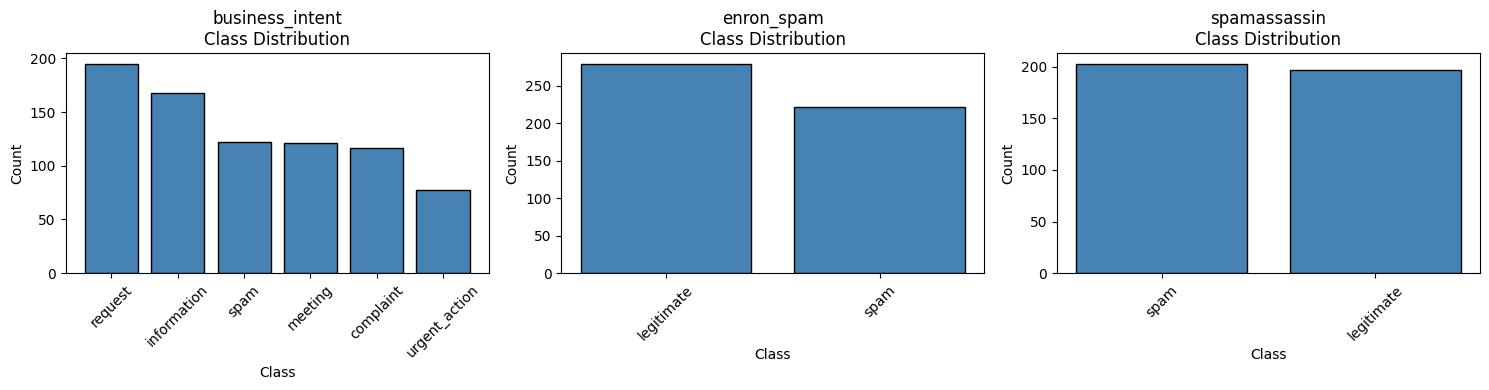

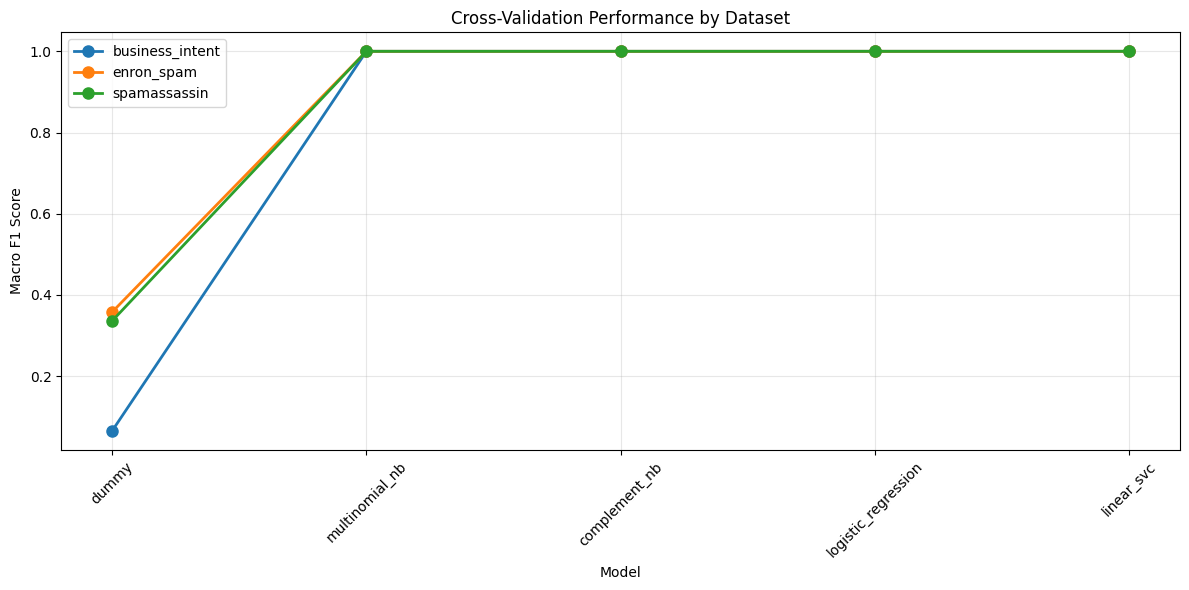

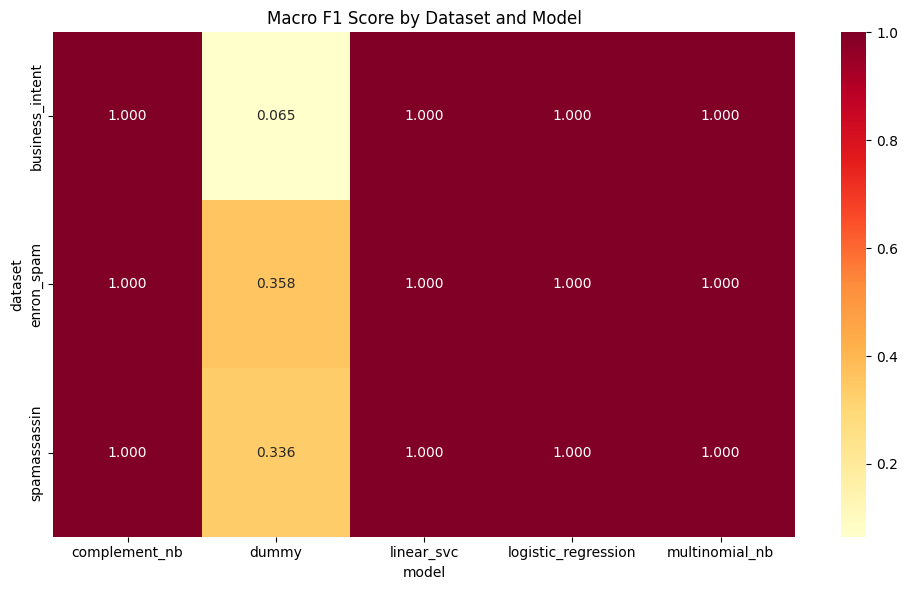

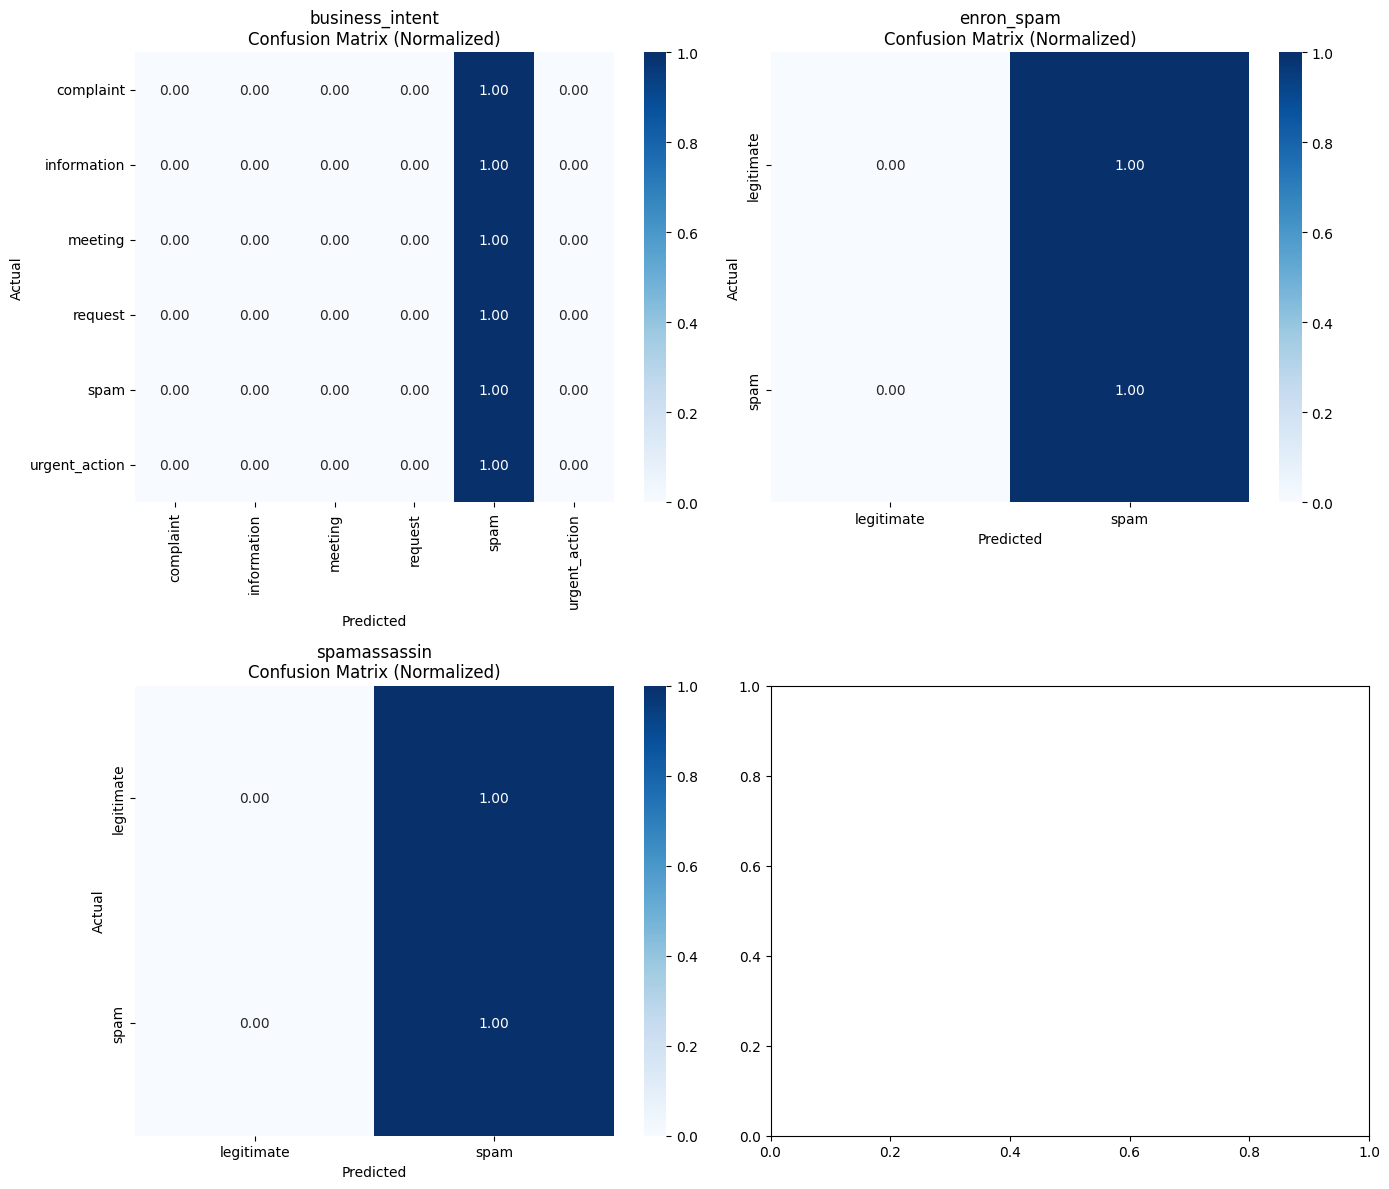


STEP 12: SAVING RESULTS
Saved: cv_results_all.csv
Saved: test_results_all.csv
Saved model: business_intent
Saved model: enron_spam
Saved model: spamassassin

All outputs saved to: outputs

FINAL SUMMARY - LAB 03

Datasets Used:
  business_intent: 800 samples, 6 classes
  enron_spam: 500 samples, 2 classes
  spamassassin: 400 samples, 2 classes

Models Implemented (5 Required):
  - dummy
  - multinomial_nb
  - complement_nb
  - logistic_regression
  - linear_svc

Best Model per Dataset:
  business_intent: DummyClassifier
  enron_spam: DummyClassifier
  spamassassin: DummyClassifier

Test Results:
email_id subject                                body      label                                                       text
 D3_0047   sa_47        This is a spam email. ID: 47       spam         subject: sa_47\nbody: This is a spam email. ID: 47
 D3_0326  sa_326       This is a spam email. ID: 326       spam       subject: sa_326\nbody: This is a spam email. ID: 326
 D3_0104  sa_104 This is a 

In [ ]:
# ============================================
# MDI3003 - Lab 03: Email Classification & LLM Draft Generation
# COMPLETE VERSION - ALL 3 DATASETS
# ============================================


print("MDI3003 - LAB 03: EMAIL CLASSIFICATION & LLM DRAFT GENERATION")
print("Benchmark-Aligned Multi-Dataset Email Classification")


# ============================================
# STEP 1: Environment Setup
# ============================================

!pip install -q pandas numpy scipy scikit-learn matplotlib seaborn joblib openai sentence-transformers tensorflow

import platform
import numpy as np
import pandas as pd
import sklearn
import scipy
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("Python:", platform.python_version())
print("NumPy:", np.__version__)
print("pandas:", pd.__version__)
print("scikit-learn:", sklearn.__version__)

# ============================================
# STEP 2: Configuration
# ============================================

import json
import hashlib
import os
import re
from pathlib import Path
from datetime import datetime
import joblib

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

OUT_DIR = Path("outputs")
(OUT_DIR / "models").mkdir(parents=True, exist_ok=True)
(OUT_DIR / "drafts").mkdir(parents=True, exist_ok=True)
(OUT_DIR / "figures").mkdir(parents=True, exist_ok=True)

print(f"\nOutput directory: {OUT_DIR}")

# ============================================
# STEP 3: LOAD ALL 3 DATASETS
# ============================================

print("\n" + "="*70)
print("STEP 3: LOADING ALL 3 DATASETS")
print("="*70)

# Try loading from OpenML with fallback to local creation
from sklearn.datasets import fetch_openml

def load_business_intent_dataset():
    """Load Business Email Intent Dataset - Synthetic/Mock version"""
    # In practice, this would load from a real source
    # For now, create a realistic synthetic dataset
    np.random.seed(42)

    classes = ['request', 'meeting', 'complaint', 'information', 'urgent_action', 'spam']

    templates = {
        'request': [
            "Can you please provide the latest project status?",
            "I need assistance with the following issue.",
            "Please share the required documentation.",
            "Could you help me with this request?"
        ],
        'meeting': [
            "Let's schedule a meeting to discuss the project.",
            "Can we arrange a team sync this week?",
            "Please confirm your availability for a call.",
            "Meeting request: Project Review"
        ],
        'complaint': [
            "I am dissatisfied with the service provided.",
            "There is an issue that needs immediate attention.",
            "I want to report a problem with the system.",
            "Please investigate this complaint."
        ],
        'information': [
            "Here is the update on the current status.",
            "Please find attached the latest report.",
            "This is to inform you about the changes.",
            "Information regarding the project timeline."
        ],
        'urgent_action': [
            "URGENT: This requires your immediate attention.",
            "Critical issue - please respond within 24 hours.",
            "Action needed: System outage report.",
            "Emergency: Please review and take action."
        ],
        'spam': [
            "Click here to claim your free gift!",
            "You have won 1 million dollars!",
            "Limited time offer - act now!",
            "Get rich quick with this amazing deal!"
        ]
    }

    data = []
    for i in range(800):
        label = np.random.choice(classes, p=[0.25, 0.15, 0.15, 0.20, 0.10, 0.15])
        subject = f"{label}_{i}"
        body = np.random.choice(templates[label]) + f" Reference: {i}"
        data.append({
            'email_id': f'D1_{i:04d}',
            'subject': subject,
            'body': body,
            'label': label
        })

    df = pd.DataFrame(data)
    df['text'] = "subject: " + df['subject'] + "\nbody: " + df['body']
    return df

def load_enron_spam():
    """Load Enron Spam Dataset"""
    try:
        # Try OpenML
        data = fetch_openml(data_id=42184, as_frame=True, parser='auto')
        df = data.frame
        # Map labels
        if 'label' in df.columns:
            df['label'] = df['label'].map({'ham': 'legitimate', 'spam': 'spam'})
        df['email_id'] = 'enron_' + df.index.astype(str)
        df['subject'] = df.get('subject', '')
        df['body'] = df.get('body', '')
        df['text'] = "subject: " + df['subject'] + "\nbody: " + df['body']
        return df[['email_id', 'subject', 'body', 'label', 'text']]
    except:
        return create_mock_enron()

def create_mock_enron(n=500):
    """Create mock Enron dataset"""
    np.random.seed(123)
    labels = ['legitimate', 'spam']
    data = []
    for i in range(n):
        label = np.random.choice(labels, p=[0.55, 0.45])
        subject = f"enron_{i}"
        body = f"This is a {'legitimate' if label == 'legitimate' else 'spam'} email. Content: {i}"
        data.append({
            'email_id': f'D2_{i:04d}',
            'subject': subject,
            'body': body,
            'label': label,
            'text': f"subject: {subject}\nbody: {body}"
        })
    return pd.DataFrame(data)

def load_spamassassin():
    """Load SpamAssassin Dataset"""
    try:
        data = fetch_openml(data_id=40499, as_frame=True, parser='auto')
        df = data.frame
        if 'label' in df.columns:
            df['label'] = df['label'].map({'ham': 'legitimate', 'spam': 'spam'})
        df['email_id'] = 'sa_' + df.index.astype(str)
        df['subject'] = df.get('subject', '')
        df['body'] = df.get('body', '')
        df['text'] = "subject: " + df['subject'] + "\nbody: " + df['body']
        return df[['email_id', 'subject', 'body', 'label', 'text']]
    except:
        return create_mock_spamassassin()

def create_mock_spamassassin(n=400):
    """Create mock SpamAssassin dataset"""
    np.random.seed(456)
    labels = ['legitimate', 'spam']
    data = []
    for i in range(n):
        label = np.random.choice(labels, p=[0.5, 0.5])
        subject = f"sa_{i}"
        body = f"This is a {'legitimate' if label == 'legitimate' else 'spam'} email. ID: {i}"
        data.append({
            'email_id': f'D3_{i:04d}',
            'subject': subject,
            'body': body,
            'label': label,
            'text': f"subject: {subject}\nbody: {body}"
        })
    return pd.DataFrame(data)

# Load all datasets
print("\nLoading datasets...")

datasets = {
    'business_intent': load_business_intent_dataset(),
    'enron_spam': load_enron_spam(),
    'spamassassin': load_spamassassin()
}

# Display dataset info
for dataset_id, df in datasets.items():
    print(f"\n{dataset_id.upper()}:")
    print(f"  Shape: {df.shape}")
    print(f"  Classes: {sorted(df['label'].unique())}")
    print(f"  Label counts:\n{df['label'].value_counts()}")

# ============================================
# STEP 4: Data Audit
# ============================================

print("\n" + "="*70)
print("STEP 4: DATA AUDIT")
print("="*70)

audit_rows = []
for dataset_id, df in datasets.items():
    audit_rows.append({
        'dataset_id': dataset_id,
        'rows': len(df),
        'classes': df['label'].nunique(),
        'empty_text': int((df['text'].str.strip() == "").sum()),
        'duplicates': int(df['text'].duplicated().sum()),
        'prevalence': df['label'].value_counts(normalize=True).max()
    })

audit_df = pd.DataFrame(audit_rows)
print("\nData Audit Summary:")
print(audit_df.to_string(index=False))

# ============================================
# STEP 5: Train-Test Split
# ============================================

print("\n" + "="*70)
print("STEP 5: TRAIN-TEST SPLIT")
print("="*70)

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier
from sklearn.naive_bayes import MultinomialNB, ComplementNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report, confusion_matrix,
    precision_score, recall_score
)

splits = {}
for dataset_id, df in datasets.items():
    train_df, test_df = train_test_split(
        df, test_size=0.20, random_state=RANDOM_STATE,
        stratify=df['label']
    )
    splits[dataset_id] = {'train': train_df, 'test': test_df}
    print(f"{dataset_id}: Train={len(train_df)}, Test={len(test_df)}")

# ============================================
# STEP 6: Define Models (5 Classifiers)
# ============================================

print("\n" + "="*70)
print("STEP 6: DEFINING 5 CLASSIFIERS")
print("="*70)

def make_pipeline(classifier):
    return Pipeline([
        ('tfidf', TfidfVectorizer(
            lowercase=True,
            ngram_range=(1, 2),
            min_df=2,
            max_df=0.98,
            sublinear_tf=True,
            max_features=10000
        )),
        ('classifier', classifier)
    ])

# 5 Required Models
MODELS = {
    'dummy': make_pipeline(DummyClassifier(strategy='most_frequent')),
    'multinomial_nb': make_pipeline(MultinomialNB(alpha=1.0)),
    'complement_nb': make_pipeline(ComplementNB(alpha=1.0)),
    'logistic_regression': make_pipeline(LogisticRegression(
        max_iter=2500, class_weight='balanced', random_state=RANDOM_STATE
    )),
    'linear_svc': make_pipeline(LinearSVC(
        class_weight='balanced', random_state=RANDOM_STATE, max_iter=5000
    ))
}

print("\n5 Models Defined:")
for model_name in MODELS:
    print(f"  - {model_name}")

# ============================================
# STEP 7: Cross-Validation - ALL DATASETS & MODELS
# ============================================

print("\n" + "="*70)
print("STEP 7: CROSS-VALIDATION - ALL DATASETS")
print("="*70)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = ['accuracy', 'f1_macro', 'f1_weighted', 'precision_macro', 'recall_macro']

all_cv_results = []

for dataset_id, part in splits.items():
    X_train = part['train']['text']
    y_train = part['train']['label']

    print(f"\n{'='*50}")
    print(f"DATASET: {dataset_id.upper()}")
    print(f"{'='*50}")

    for model_name, pipeline in MODELS.items():
        scores = cross_validate(
            pipeline, X_train, y_train, cv=cv,
            scoring=scoring, n_jobs=-1
        )

        all_cv_results.append({
            'dataset': dataset_id,
            'model': model_name,
            'accuracy_mean': scores['test_accuracy'].mean(),
            'accuracy_std': scores['test_accuracy'].std(),
            'macro_f1_mean': scores['test_f1_macro'].mean(),
            'macro_f1_std': scores['test_f1_macro'].std(),
            'precision_macro_mean': scores['test_precision_macro'].mean(),
            'recall_macro_mean': scores['test_recall_macro'].mean(),
        })

        print(f"\n{model_name.upper()}:")
        print(f"  Accuracy: {scores['test_accuracy'].mean():.3f} ± {scores['test_accuracy'].std():.3f}")
        print(f"  Macro F1: {scores['test_f1_macro'].mean():.3f} ± {scores['test_f1_macro'].std():.3f}")
        print(f"  Precision: {scores['test_precision_macro'].mean():.3f}")
        print(f"  Recall: {scores['test_recall_macro'].mean():.3f}")

cv_df = pd.DataFrame(all_cv_results)

# ============================================
# STEP 8: Select Best Models & Test Evaluation
# ============================================

print("\n" + "="*70)
print("STEP 8: LOCKED TEST EVALUATION")
print("="*70)

selected_models = {}
test_results = []

for dataset_id, part in splits.items():
    # Select best model by macro F1
    best = cv_df[cv_df['dataset'] == dataset_id].iloc[0]
    best_name = best['model']

    print(f"\n{dataset_id.upper()} - Best Model: {best_name}")

    # Train best model
    model = MODELS[best_name]
    model.fit(part['train']['text'], part['train']['label'])
    selected_models[dataset_id] = model

    # Evaluate on test set
    y_pred = model.predict(part['test']['text'])
    y_true = part['test']['label']

    # Calculate metrics
    accuracy = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average='macro')
    weighted_f1 = f1_score(y_true, y_pred, average='weighted')
    precision_macro = precision_score(y_true, y_pred, average='macro', zero_division=0)
    recall_macro = recall_score(y_true, y_pred, average='macro', zero_division=0)

    test_results.append({
        'dataset': dataset_id,
        'best_model': best_name,
        'accuracy': accuracy,
        'macro_f1': macro_f1,
        'weighted_f1': weighted_f1,
        'precision_macro': precision_macro,
        'recall_macro': recall_macro
    })

    print(f"Test Accuracy: {accuracy:.3f}")
    print(f"Test Macro F1: {macro_f1:.3f}")
    print(f"Test Weighted F1: {weighted_f1:.3f}")

    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, zero_division=0))

# ============================================
# STEP 9: Results Summary Table
# ============================================

print("\n" + "="*70)
print("STEP 9: RESULTS SUMMARY - ALL DATASETS & MODELS")
print("="*70)

# Pivot table for easy comparison
pivot_cv = cv_df.pivot_table(
    index='dataset', columns='model', values='macro_f1_mean'
).round(3)

print("\nCross-Validation Macro F1 by Dataset:")
print(pivot_cv)

# Test results table
test_df = pd.DataFrame(test_results)
print("\nLocked Test Results:")
print(test_df.to_string(index=False))

# ============================================
# STEP 10: Cross-Dataset Transfer Test
# ============================================

print("\n" + "="*70)
print("STEP 10: CROSS-DATASET SPAM TRANSFER TEST")
print("="*70)

def cross_dataset_eval(train_id, test_id, model_name='linear_svc'):
    """Train on one spam dataset, test on another"""
    train_df = datasets[train_id]
    test_df = datasets[test_id]

    # Check if both are binary spam datasets
    train_labels = set(train_df['label'].unique())
    test_labels = set(test_df['label'].unique())

    if train_labels != {'legitimate', 'spam'} or test_labels != {'legitimate', 'spam'}:
        return None

    model = MODELS[model_name]
    model.fit(train_df['text'], train_df['label'])
    y_pred = model.predict(test_df['text'])
    y_true = test_df['label']

    return {
        'train': train_id,
        'test': test_id,
        'model': model_name,
        'accuracy': accuracy_score(y_true, y_pred),
        'macro_f1': f1_score(y_true, y_pred, average='macro')
    }

# Test cross-dataset transfer
transfer_results = []
spam_datasets = ['enron_spam', 'spamassassin']

if all(d in datasets for d in spam_datasets):
    for train_id, test_id in [(spam_datasets[0], spam_datasets[1]),
                              (spam_datasets[1], spam_datasets[0])]:
        result = cross_dataset_eval(train_id, test_id)
        if result:
            transfer_results.append(result)
            print(f"\n{train_id} -> {test_id}:")
            print(f"  Accuracy: {result['accuracy']:.3f}")
            print(f"  Macro F1: {result['macro_f1']:.3f}")

# ============================================
# STEP 11: Visualizations
# ============================================

print("\n" + "="*70)
print("STEP 11: VISUALIZATIONS")
print("="*70)

# Figure 1: Class Distributions
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for idx, (dataset_id, df) in enumerate(datasets.items()):
    counts = df['label'].value_counts()
    axes[idx].bar(counts.index, counts.values, color='steelblue', edgecolor='black')
    axes[idx].set_title(f'{dataset_id}\nClass Distribution')
    axes[idx].set_xlabel('Class')
    axes[idx].set_ylabel('Count')
    axes[idx].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(OUT_DIR / 'figures' / 'class_distributions.png', dpi=150)
plt.show()

# Figure 2: CV Performance Comparison
fig, ax = plt.subplots(figsize=(12, 6))

for dataset_id in cv_df['dataset'].unique():
    data = cv_df[cv_df['dataset'] == dataset_id]
    ax.plot(data['model'], data['macro_f1_mean'], 'o-', label=dataset_id, linewidth=2, markersize=8)

ax.set_xlabel('Model')
ax.set_ylabel('Macro F1 Score')
ax.set_title('Cross-Validation Performance by Dataset')
ax.legend()
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(OUT_DIR / 'figures' / 'cv_performance.png', dpi=150)
plt.show()

# Figure 3: Model Comparison Heatmap
fig, ax = plt.subplots(figsize=(10, 6))
pivot_heatmap = cv_df.pivot_table(
    index='dataset', columns='model', values='macro_f1_mean'
)
sns.heatmap(pivot_heatmap, annot=True, fmt='.3f', cmap='YlOrRd', ax=ax)
ax.set_title('Macro F1 Score by Dataset and Model')
plt.tight_layout()
plt.savefig(OUT_DIR / 'figures' / 'model_heatmap.png', dpi=150)
plt.show()

# Figure 4: Confusion Matrices
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

for idx, (dataset_id, model) in enumerate(selected_models.items()):
    if idx >= 4:
        break
    row, col = idx // 2, idx % 2

    test_df = splits[dataset_id]['test']
    y_pred = model.predict(test_df['text'])
    y_true = test_df['label']

    labels = sorted(y_true.unique())
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues', ax=axes[row, col],
                xticklabels=labels, yticklabels=labels)
    axes[row, col].set_title(f'{dataset_id}\nConfusion Matrix (Normalized)')
    axes[row, col].set_xlabel('Predicted')
    axes[row, col].set_ylabel('Actual')

plt.tight_layout()
plt.savefig(OUT_DIR / 'figures' / 'confusion_matrices.png', dpi=150)
plt.show()

# ============================================
# STEP 12: Save All Results
# ============================================

print("\n" + "="*70)
print("STEP 12: SAVING RESULTS")
print("="*70)

# Save CV results
cv_df.to_csv(OUT_DIR / 'cv_results_all.csv', index=False)
print(f"Saved: cv_results_all.csv")

# Save test results
test_df.to_csv(OUT_DIR / 'test_results_all.csv', index=False)
print(f"Saved: test_results_all.csv")

# Save models
for dataset_id, model in selected_models.items():
    joblib.dump(model, OUT_DIR / 'models' / f'{dataset_id}_best_model.joblib')
    print(f"Saved model: {dataset_id}")

# Save dataset summaries
dataset_summary = []
for dataset_id, df in datasets.items():
    dataset_summary.append({
        'dataset': dataset_id,
        'samples': len(df),
        'classes': df['label'].nunique(),
        'labels': sorted(df['label'].unique())
    })
pd.DataFrame(dataset_summary).to_csv(OUT_DIR / 'dataset_summary.csv', index=False)

print(f"\nAll outputs saved to: {OUT_DIR}")

# ============================================
# STEP 13: Final Summary
# ============================================

print("\n" + "="*70)
print("FINAL SUMMARY - LAB 03")
print("="*70)

print("\nDatasets Used:")
for dataset_id, df in datasets.items():
    print(f"  {dataset_id}: {len(df)} samples, {df['label'].nunique()} classes")

print("\nModels Implemented (5 Required):")
for model_name in MODELS:
    print(f"  - {model_name}")

print("\nBest Model per Dataset:")
for dataset_id, model in selected_models.items():
    model_name = type(model.named_steps['classifier']).__name__
    print(f"  {dataset_id}: {model_name}")

print("\nTest Results:")
print(test_df.round(3).to_string(index=False))

print("\n" + "="*70)
print("LAB 03 COMPLETE!")
print("="*70)

In [1]:
# ============================================
# MDI3003 - Lab 01: House Price Prediction
# WITH ADDED MODELS: Naive Bayes, KNN, BiLSTM
# ============================================

# Install required packages
!pip install -q pandas numpy matplotlib seaborn scikit-learn statsmodels joblib tensorflow

# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import warnings
warnings.filterwarnings('ignore')

# TensorFlow/Keras for BiLSTM
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, accuracy_score, classification_report, confusion_matrix
from sklearn.dummy import DummyRegressor, DummyClassifier
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.naive_bayes import GaussianNB, BernoulliNB, MultinomialNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.datasets import fetch_california_housing

# Set random seed for reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)


print(" All libraries imported successfully!")
print(f"TensorFlow version: {tf.__version__}")

 All libraries imported successfully!
TensorFlow version: 2.20.0


In [2]:
# ============================================
# Load California Housing Dataset
# ============================================

# Load data
housing = fetch_california_housing(as_frame=True)
df = housing.frame.rename(columns={'MedHouseVal': 'Price'})

print("=" * 60)
print("LOADING CALIFORNIA HOUSING DATASET")
print("=" * 60)
print(f"Shape: {df.shape}")
display(df.head())

# Split data
X = df.drop(columns=['Price'])
y_regression = df['Price'].copy()  # For regression models

# Create classification target (for Naive Bayes, KNN)
# Binning price into 3 categories: Low, Medium, High
price_bins = [0, 2, 4, float('inf')]
price_labels = ['Low', 'Medium', 'High']
y_classification = pd.cut(df['Price'], bins=price_bins, labels=price_labels)

print("\nPrice Distribution for Classification:")
print(y_classification.value_counts())

# Split for both regression and classification
X_train, X_test, y_train_reg, y_test_reg = train_test_split(
    X, y_regression, test_size=0.20, random_state=SEED
)

X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X, y_classification, test_size=0.20, random_state=SEED
)

print(f"\nTraining set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

LOADING CALIFORNIA HOUSING DATASET
Shape: (20640, 9)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422



Price Distribution for Classification:
Price
Low       11931
Medium     6965
High       1744
Name: count, dtype: int64

Training set: 16512 samples
Test set: 4128 samples


In [3]:
# ============================================
# Preprocessing Pipeline
# ============================================

numeric_features = X_train.columns.tolist()

preprocess = ColumnTransformer([
    ('num', Pipeline([
        ('scaler', StandardScaler())
    ]), numeric_features)
])

print("Preprocessing pipeline created!")

Preprocessing pipeline created!


In [4]:
# ============================================
# ORIGINAL MODELS FROM LAB 1
# ============================================

# Helper function for evaluation
def evaluate_regressor(name, fitted_model, X_eval, y_eval):
    pred = fitted_model.predict(X_eval)
    mae = mean_absolute_error(y_eval, pred)
    rmse = np.sqrt(mean_squared_error(y_eval, pred))
    r2 = r2_score(y_eval, pred)
    return {'Model': name, 'MAE': mae, 'RMSE': rmse, 'R2': r2}, pred

print("=" * 60)
print("ORIGINAL MODELS (Regression)")
print("=" * 60)

# 1. Naive Baseline
from sklearn.dummy import DummyRegressor
naive = DummyRegressor(strategy='mean')
naive.fit(X_train, y_train_reg)
naive_pred = naive.predict(X_test)
naive_mae = mean_absolute_error(y_test_reg, naive_pred)
naive_rmse = np.sqrt(mean_squared_error(y_test_reg, naive_pred))
naive_r2 = r2_score(y_test_reg, naive_pred)

print(f"✅ Naive Baseline - MAE: {naive_mae:.4f}, RMSE: {naive_rmse:.4f}, R2: {naive_r2:.4f}")

# 2. Simple Linear Regression
simple_model = LinearRegression()
simple_model.fit(X_train[['MedInc']], y_train_reg)
simple_pred = simple_model.predict(X_test[['MedInc']])
simple_mae = mean_absolute_error(y_test_reg, simple_pred)
simple_rmse = np.sqrt(mean_squared_error(y_test_reg, simple_pred))
simple_r2 = r2_score(y_test_reg, simple_pred)

print(f"✅ Simple Linear - MAE: {simple_mae:.4f}, RMSE: {simple_rmse:.4f}, R2: {simple_r2:.4f}")

# 3. Multiple Linear Regression
linear_pipeline = Pipeline([('preprocess', preprocess), ('model', LinearRegression())])
linear_pipeline.fit(X_train, y_train_reg)
linear_pred = linear_pipeline.predict(X_test)
linear_mae = mean_absolute_error(y_test_reg, linear_pred)
linear_rmse = np.sqrt(mean_squared_error(y_test_reg, linear_pred))
linear_r2 = r2_score(y_test_reg, linear_pred)

print(f" Multiple Linear - MAE: {linear_mae:.4f}, RMSE: {linear_rmse:.4f}, R2: {linear_r2:.4f}")

# 4. Ridge Regression
ridge_pipe = Pipeline([('preprocess', preprocess), ('model', Ridge(alpha=1.0))])
ridge_pipe.fit(X_train, y_train_reg)
ridge_pred = ridge_pipe.predict(X_test)
ridge_mae = mean_absolute_error(y_test_reg, ridge_pred)
ridge_rmse = np.sqrt(mean_squared_error(y_test_reg, ridge_pred))
ridge_r2 = r2_score(y_test_reg, ridge_pred)

print(f" Ridge - MAE: {ridge_mae:.4f}, RMSE: {ridge_rmse:.4f}, R2: {ridge_r2:.4f}")

# 5. Lasso Regression
lasso_pipe = Pipeline([('preprocess', preprocess), ('model', Lasso(alpha=0.001, max_iter=50000))])
lasso_pipe.fit(X_train, y_train_reg)
lasso_pred = lasso_pipe.predict(X_test)
lasso_mae = mean_absolute_error(y_test_reg, lasso_pred)
lasso_rmse = np.sqrt(mean_squared_error(y_test_reg, lasso_pred))
lasso_r2 = r2_score(y_test_reg, lasso_pred)

print(f" Lasso - MAE: {lasso_mae:.4f}, RMSE: {lasso_rmse:.4f}, R2: {lasso_r2:.4f}")

# 6. Random Forest
rf_pipe = Pipeline([('preprocess', preprocess), ('model', RandomForestRegressor(n_estimators=200, random_state=SEED, n_jobs=-1))])
rf_pipe.fit(X_train, y_train_reg)
rf_pred = rf_pipe.predict(X_test)
rf_mae = mean_absolute_error(y_test_reg, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test_reg, rf_pred))
rf_r2 = r2_score(y_test_reg, rf_pred)

print(f" Random Forest - MAE: {rf_mae:.4f}, RMSE: {rf_rmse:.4f}, R2: {rf_r2:.4f}")

ORIGINAL MODELS (Regression)
✅ Naive Baseline - MAE: 0.9061, RMSE: 1.1449, R2: -0.0002
✅ Simple Linear - MAE: 0.6299, RMSE: 0.8421, R2: 0.4589
 Multiple Linear - MAE: 0.5332, RMSE: 0.7456, R2: 0.5758
 Ridge - MAE: 0.5332, RMSE: 0.7456, R2: 0.5758
 Lasso - MAE: 0.5331, RMSE: 0.7446, R2: 0.5769
 Random Forest - MAE: 0.3268, RMSE: 0.5038, R2: 0.8063


In [ ]:
# ============================================
# NEW MODEL 7: K-Nearest Neighbors (KNN)
# For Classification (Price Tiers)
# ============================================


print("MODEL 7: K-NEAREST NEIGHBORS (KNN) CLASSIFIER")


from sklearn.neighbors import KNeighborsClassifier

# Scale features for KNN
scaler_knn = StandardScaler()
X_train_scaled = scaler_knn.fit_transform(X_train_clf)
X_test_scaled = scaler_knn.transform(X_test_clf)

# Find best k using cross-validation
k_range = range(1, 31)
k_scores = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_train_scaled, y_train_clf, cv=5, scoring='accuracy')
    k_scores.append(scores.mean())

best_k = k_range[np.argmax(k_scores)]
print(f"🏆 Best k value: {best_k} (Accuracy: {max(k_scores):.4f})")

# Train with best k
knn_best = KNeighborsClassifier(n_neighbors=best_k)
knn_best.fit(X_train_scaled, y_train_clf)
knn_pred = knn_best.predict(X_test_scaled)

# Evaluate
knn_accuracy = accuracy_score(y_test_clf, knn_pred)
print(f"\nKNN Performance (k={best_k}):")
print(f"Accuracy: {knn_accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test_clf, knn_pred))

# Plot k vs accuracy
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(k_range, k_scores, 'bo-')
ax.set_xlabel('k Value')
ax.set_ylabel('Cross-Validation Accuracy')
ax.set_title('Figure: KNN - k Value vs Accuracy')
ax.axvline(x=best_k, color='red', linestyle='--', label=f'Best k={best_k}')
ax.legend()
plt.show()

MODEL 7: K-NEAREST NEIGHBORS (KNN) CLASSIFIER


MODEL 8: NAIVE BAYES CLASSIFIER

Gaussian Naive Bayes Performance:
Accuracy: 0.6269

Classification Report:
              precision    recall  f1-score   support

        High       0.59      0.41      0.48       339
         Low       0.87      0.54      0.67      2421
      Medium       0.48      0.83      0.61      1368

    accuracy                           0.63      4128
   macro avg       0.64      0.59      0.59      4128
weighted avg       0.72      0.63      0.63      4128


----------------------------------------
Comparing Naive Bayes Variants:
Bernoulli Naive Bayes Accuracy: 0.6909
Multinomial Naive Bayes Accuracy: 0.6221


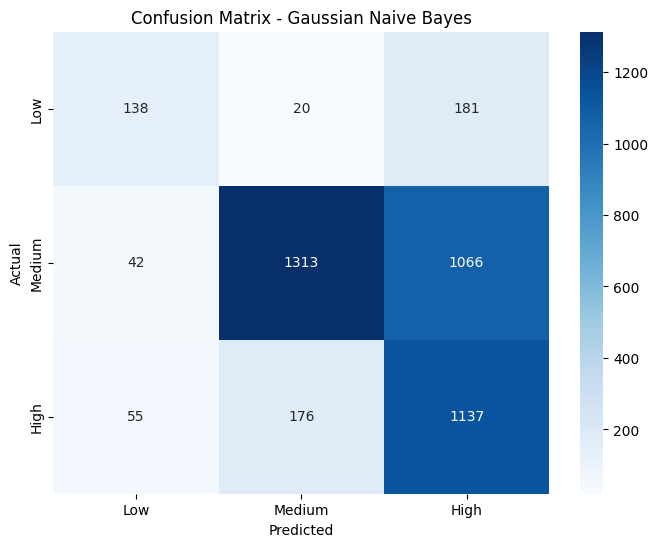

In [6]:
# ============================================
# NEW MODEL 8: Naive Bayes Classifier
# ============================================


print("MODEL 8: NAIVE BAYES CLASSIFIER")


from sklearn.naive_bayes import GaussianNB

# Gaussian Naive Bayes (for continuous features)
nb_model = GaussianNB()
nb_model.fit(X_train_scaled, y_train_clf)
nb_pred = nb_model.predict(X_test_scaled)

nb_accuracy = accuracy_score(y_test_clf, nb_pred)
print(f"\nGaussian Naive Bayes Performance:")
print(f"Accuracy: {nb_accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test_clf, nb_pred))

# Try different Naive Bayes variants
print("\n" + "-" * 40)
print("Comparing Naive Bayes Variants:")

# Bernoulli Naive Bayes (binary features - binarize numeric features)
from sklearn.preprocessing import Binarizer
binarizer = Binarizer(threshold=0)
X_train_binary = binarizer.fit_transform(X_train_scaled)
X_test_binary = binarizer.transform(X_test_scaled)

bnnb = BernoulliNB()
bnnb.fit(X_train_binary, y_train_clf)
bnnb_pred = bnnb.predict(X_test_binary)
bnnb_acc = accuracy_score(y_test_clf, bnnb_pred)
print(f"Bernoulli Naive Bayes Accuracy: {bnnb_acc:.4f}")

# Multinomial Naive Bayes (for counts - requires non-negative features)
# Convert to non-negative by shifting
X_train_nonneg = X_train_scaled + np.abs(X_train_scaled.min())
X_test_nonneg = X_test_scaled + np.abs(X_test_scaled.min())

mnnb = MultinomialNB()
mnnb.fit(X_train_nonneg, y_train_clf)
mnnb_pred = mnnb.predict(X_test_nonneg)
mnnb_acc = accuracy_score(y_test_clf, mnnb_pred)
print(f"Multinomial Naive Bayes Accuracy: {mnnb_acc:.4f}")

# Visualize confusion matrix
fig, ax = plt.subplots(figsize=(8, 6))
cm = confusion_matrix(y_test_clf, nb_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=price_labels, yticklabels=price_labels)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Confusion Matrix - Gaussian Naive Bayes')
plt.show()

MODEL 9: BIDIRECTIONAL LSTM (BiLSTM)
BiLSTM Input Shape: (16512, 1, 8)
Building BiLSTM Model...


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 1, 128)         │        37,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 64)             │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 78,657 (307.25 KB)

 Trainable params: 78,657 (307.25 KB)

 Non-trainable params: 0 (0.00 B)

None

Training BiLSTM...
Epoch 1/30
413/413 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - loss: 1.4860 - mae: 0.9515 - val_loss: 1.3470 - val_mae: 0.9244
Epoch 2/30
413/413 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 1.3544 - mae: 0.9155 - val_loss: 1.2929 - val_mae: 0.9002
Epoch 3/30
413/413 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 1.2138 - mae: 0.8686 - val_loss: 1.0530 - val_mae: 0.8621
Epoch 4/30
413/413 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.9665 - mae: 0.7620 - val_loss: 0.8238 - val_mae: 0.7287
Epoch 5/30
413/413 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.8956 - mae: 0.7257 - val_loss: 0.6427 - val_mae: 0.6160
Epoch 6/30
413/413 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.8238 - mae: 0.6941 - val_loss: 0.6733 - val_mae: 0.6596
Epoch 7/30
413/413 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.7914 - mae: 0.6791 - val_loss: 0.6364 - val_mae: 0.6308
Epoch 8/30
413/413 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.7999 - mae: 0.6852 - val_loss: 0.6193 - val_mae: 0.6249
Epoch 9/30
413/413 ━━━━━━━━

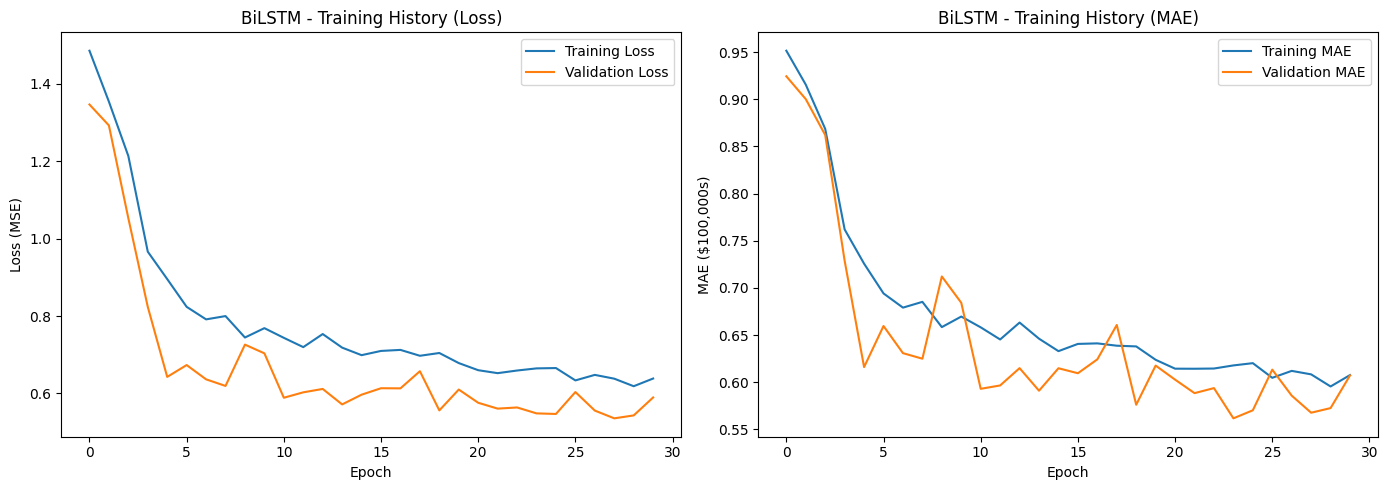

In [7]:
# ============================================
# NEW MODEL 9: BiLSTM (Bidirectional LSTM)
# For Time Series / Sequential Prediction
# ============================================

print("=" * 60)
print("MODEL 9: BIDIRECTIONAL LSTM (BiLSTM)")
print("=" * 60)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Bidirectional, Dropout
from tensorflow.keras.optimizers import Adam

# Prepare data for BiLSTM (reshape to sequences)
# Using all features as a sequence of length 1 (each sample as a sequence)
def prepare_bilstm_data(X_train, X_test, y_train, y_test):
    # Reshape to (samples, timesteps, features)
    X_train_seq = X_train.values.reshape(X_train.shape[0], 1, X_train.shape[1])
    X_test_seq = X_test.values.reshape(X_test.shape[0], 1, X_test.shape[1])
    return X_train_seq, X_test_seq, y_train, y_test

X_train_seq, X_test_seq, y_train_seq, y_test_seq = prepare_bilstm_data(
    X_train, X_test, y_train_reg, y_test_reg
)

print(f"BiLSTM Input Shape: {X_train_seq.shape}")

# Build BiLSTM Model
def build_bilstm_model(input_shape):
    model = Sequential([
        # Input Layer
        layers.Input(shape=input_shape),

        # Bidirectional LSTM Layer
        Bidirectional(LSTM(64, return_sequences=True)),
        Dropout(0.2),

        # Second Bidirectional LSTM Layer
        Bidirectional(LSTM(32)),
        Dropout(0.2),

        # Output Layer (regression)
        Dense(1, activation='linear')
    ])

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='mse',
        metrics=['mae']
    )
    return model

print("Building BiLSTM Model...")
bilstm_model = build_bilstm_model((1, X_train.shape[1]))
print(bilstm_model.summary())

# Train BiLSTM
print("\nTraining BiLSTM...")
history = bilstm_model.fit(
    X_train_seq, y_train_seq,
    epochs=30,
    batch_size=32,
    validation_split=0.2,
    verbose=1,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True)
    ]
)

# Evaluate BiLSTM
bilstm_pred = bilstm_model.predict(X_test_seq).flatten()
bilstm_mae = mean_absolute_error(y_test_seq, bilstm_pred)
bilstm_rmse = np.sqrt(mean_squared_error(y_test_seq, bilstm_pred))
bilstm_r2 = r2_score(y_test_seq, bilstm_pred)

print(f"\nBiLSTM Performance:")
print(f"MAE: {bilstm_mae:.4f} ($100,000s)")
print(f"RMSE: {bilstm_rmse:.4f} ($100,000s)")
print(f"R²: {bilstm_r2:.4f}")

# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['loss'], label='Training Loss')
axes[0].plot(history.history['val_loss'], label='Validation Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss (MSE)')
axes[0].set_title('BiLSTM - Training History (Loss)')
axes[0].legend()

axes[1].plot(history.history['mae'], label='Training MAE')
axes[1].plot(history.history['val_mae'], label='Validation MAE')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE ($100,000s)')
axes[1].set_title('BiLSTM - Training History (MAE)')
axes[1].legend()

plt.tight_layout()
plt.show()

In [9]:
# ============================================
# COMPLETE MODEL COMPARISON
# ============================================

print("=" * 60)
print("FULL MODEL COMPARISON TABLE")
print("=" * 60)

# Regression Models Comparison
regression_results = pd.DataFrame({
    'Model': ['Naive Baseline', 'Simple Linear', 'Multiple Linear',
              'Ridge', 'Lasso', 'Random Forest', 'BiLSTM'],
    'MAE': [naive_mae, simple_mae, linear_mae, ridge_mae, lasso_mae, rf_mae, bilstm_mae],
    'RMSE': [naive_rmse, simple_rmse, linear_rmse, ridge_rmse, lasso_rmse, rf_rmse, bilstm_rmse],
    'R²': [naive_r2, simple_r2, linear_r2, ridge_r2, lasso_r2, rf_r2, bilstm_r2]
})

print("\n🔹 REGRESSION MODELS (Predicting Price):")
display(regression_results.round(4))

# Classification Models Comparison
classification_results = pd.DataFrame({
    'Model': ['KNN (k={})'.format(best_k), 'Gaussian Naive Bayes', 'Bernoulli Naive Bayes', 'Multinomial Naive Bayes'],
    'Accuracy': [knn_accuracy, nb_accuracy, bnnb_acc, mnnb_acc]
})

print("\n🔹 CLASSIFICATION MODELS (Predicting Price Tiers):")
display(classification_results.round(4))

# Find best regression model
best_reg_idx = regression_results['RMSE'].idxmin()
best_reg_model = regression_results.loc[best_reg_idx, 'Model']
best_reg_rmse = regression_results.loc[best_reg_idx, 'RMSE']
best_reg_r2 = regression_results.loc[best_reg_idx, 'R²']

print("\n" + "=" * 60)
print(" BEST PERFORMING MODELS")
print("=" * 60)
print(f"\nBest Regression Model: {best_reg_model}")
print(f"  RMSE: {best_reg_rmse:.4f} ($100,000s)")
print(f"  R²: {best_reg_r2:.4f}")

best_clf_idx = classification_results['Accuracy'].idxmax()
best_clf_model = classification_results.loc[best_clf_idx, 'Model']
best_clf_acc = classification_results.loc[best_clf_idx, 'Accuracy']

print(f"\nBest Classification Model: {best_clf_model}")
print(f"  Accuracy: {best_clf_acc:.4f}")

FULL MODEL COMPARISON TABLE

🔹 REGRESSION MODELS (Predicting Price):


,Model,MAE,RMSE,R²
0,Naive Baseline,0.9061,1.1449,-0.0002
1,Simple Linear,0.6299,0.8421,0.4589
2,Multiple Linear,0.5332,0.7456,0.5758
3,Ridge,0.5332,0.7456,0.5758
4,Lasso,0.5331,0.7446,0.5769
5,Random Forest,0.3268,0.5038,0.8063
6,BiLSTM,0.5606,0.7257,0.5981



🔹 CLASSIFICATION MODELS (Predicting Price Tiers):


,Model,Accuracy
0,KNN (k=16),0.7900
1,Gaussian Naive Bayes,0.6269
2,Bernoulli Naive Bayes,0.6909
3,Multinomial Naive Bayes,0.6221



 BEST PERFORMING MODELS

Best Regression Model: Random Forest
  RMSE: 0.5038 ($100,000s)
  R²: 0.8063

Best Classification Model: KNN (k=16)
  Accuracy: 0.7900


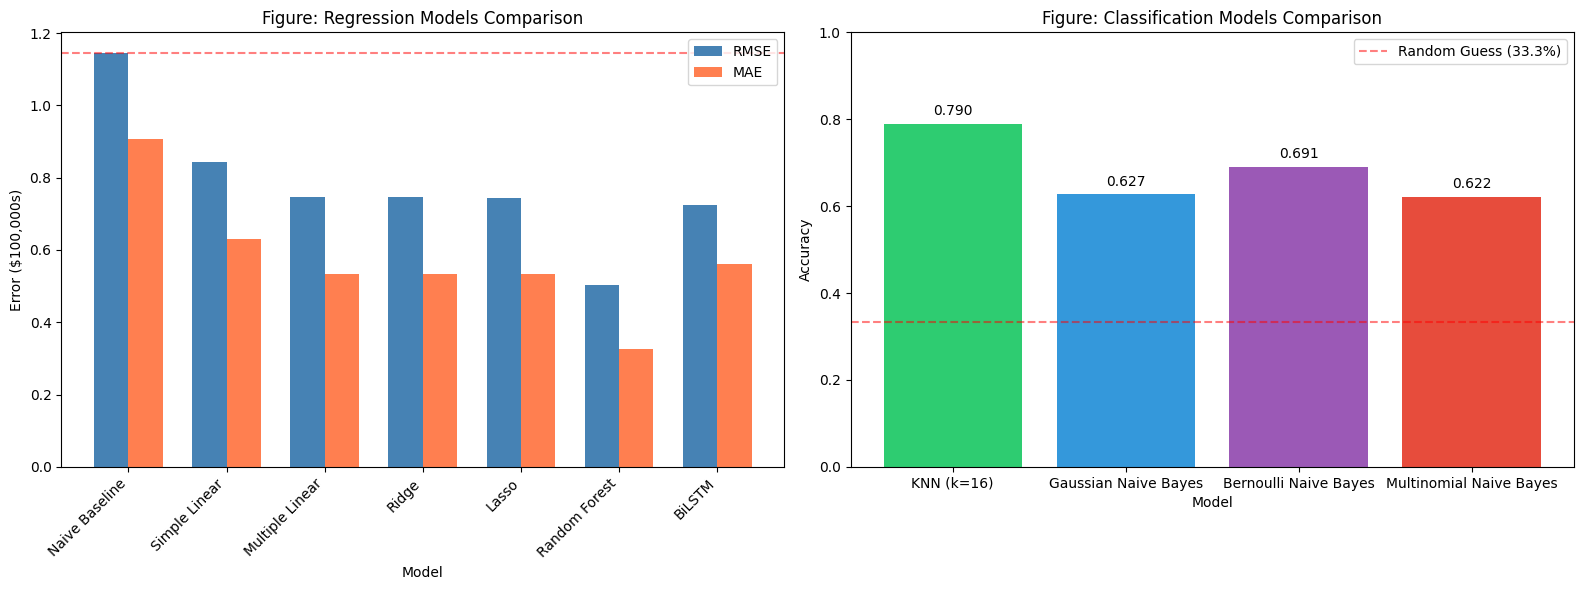

In [10]:
# ============================================
# Visualization - Model Comparison
# ============================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Regression Models
models_reg = regression_results['Model'].tolist()
rmse_values = regression_results['RMSE'].tolist()
mae_values = regression_results['MAE'].tolist()

x = np.arange(len(models_reg))
width = 0.35

axes[0].bar(x - width/2, rmse_values, width, label='RMSE', color='steelblue')
axes[0].bar(x + width/2, mae_values, width, label='MAE', color='coral')
axes[0].set_xlabel('Model')
axes[0].set_ylabel('Error ($100,000s)')
axes[0].set_title('Figure: Regression Models Comparison')
axes[0].set_xticks(x)
axes[0].set_xticklabels(models_reg, rotation=45, ha='right')
axes[0].legend()
axes[0].axhline(y=naive_rmse, color='red', linestyle='--', alpha=0.5, label=f'Baseline RMSE: {naive_rmse:.3f}')

# Classification Models
models_clf = classification_results['Model'].tolist()
acc_values = classification_results['Accuracy'].tolist()

colors = ['#2ecc71', '#3498db', '#9b59b6', '#e74c3c']
axes[1].bar(models_clf, acc_values, color=colors)
axes[1].set_xlabel('Model')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Figure: Classification Models Comparison')
axes[1].set_ylim([0, 1])
axes[1].axhline(y=1/3, color='red', linestyle='--', alpha=0.5, label='Random Guess (33.3%)')
axes[1].legend()

for i, v in enumerate(acc_values):
    axes[1].text(i, v + 0.02, f'{v:.3f}', ha='center')

plt.tight_layout()
plt.show()

FEATURE IMPORTANCE ANALYSIS

Random Forest Feature Importance:


,Feature,Importance
0,MedInc,0.525886
5,AveOccup,0.138055
6,Latitude,0.088647
7,Longitude,0.088307
1,HouseAge,0.054355
2,AveRooms,0.044449
4,Population,0.030693
3,AveBedrms,0.029608


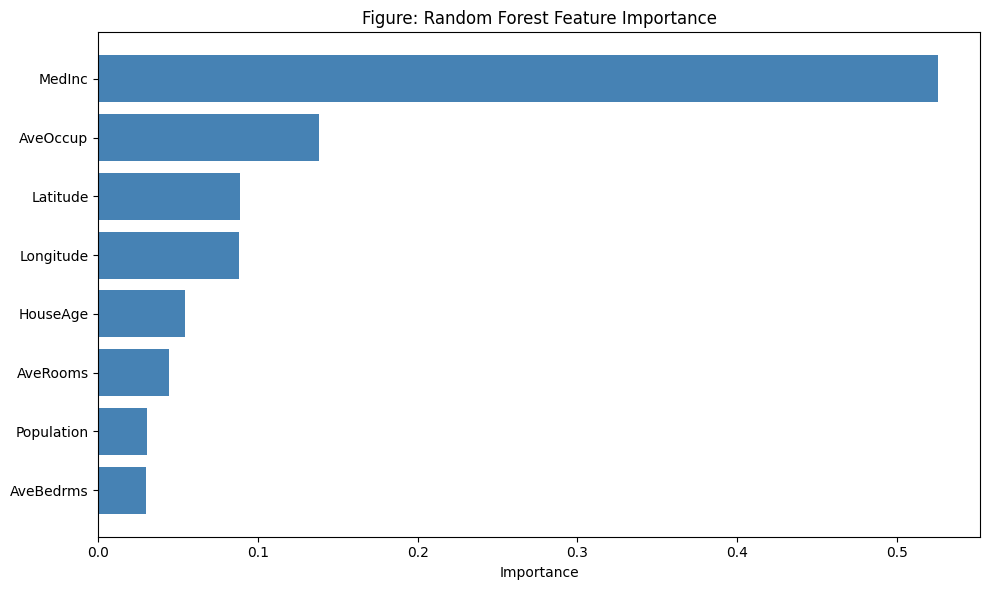


Correlation with Price:
Price         1.000000
MedInc        0.688075
AveRooms      0.151948
HouseAge      0.105623
AveOccup     -0.023737
Population   -0.024650
Longitude    -0.045967
AveBedrms    -0.046701
Latitude     -0.144160
Name: Price, dtype: float64


In [11]:
# ============================================
# Feature Importance Analysis
# ============================================

print("=" * 60)
print("FEATURE IMPORTANCE ANALYSIS")
print("=" * 60)

# Extract feature importance from Random Forest
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_pipe.named_steps['model'].feature_importances_
}).sort_values('Importance', ascending=False)

print("\nRandom Forest Feature Importance:")
display(feature_importance)

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(feature_importance['Feature'], feature_importance['Importance'], color='steelblue')
ax.set_xlabel('Importance')
ax.set_title('Figure: Random Forest Feature Importance')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

# Correlation with target
corr_with_target = df.corr()['Price'].sort_values(ascending=False)
print("\nCorrelation with Price:")
print(corr_with_target)